In [76]:
%load_ext autoreload
%autoreload 2
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
np.warnings = warnings

import torch
import random
import math
import sys
sys.path.append("../..")  # Add parent directory to path
sys.path.append("../../../..")
from simple_synth import SimpleSynth
import scipy
import matplotlib
import matplotlib.pyplot as plt
from src.model.utils import general_power_transform
from functools import partial

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


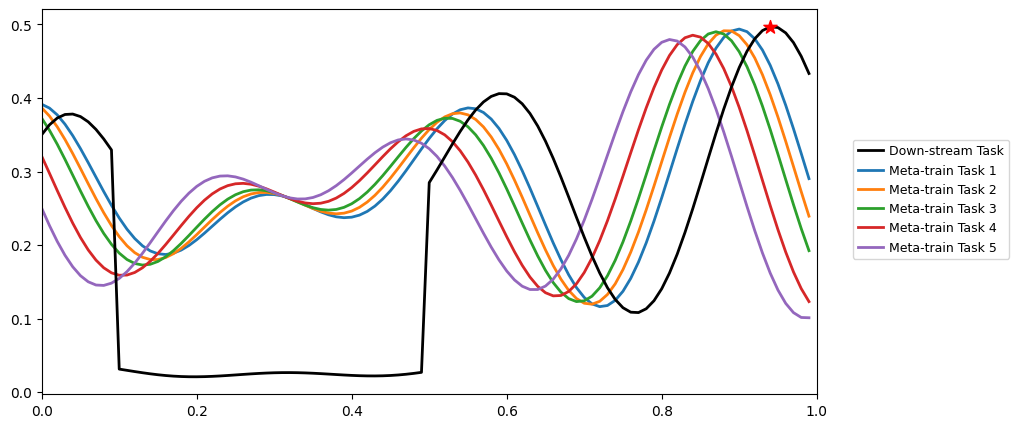

In [253]:
test_seed = "test2"
task_id = 0 # Task ID for the SimpleSynth benchmark
max_evaluations = 20
fontsize = 18
lw=2


seed_num = int(''.join(filter(str.isdigit, test_seed)))
torch.manual_seed(seed_num)
np.random.seed(seed_num)
random.seed(seed_num)

benchmark = SimpleSynth(seed=test_seed, start_task=task_id, initializations=3)
#meta_data = benchmark.get_meta_data(task_ids=[3, 4, 5, 7, 11])
meta_data = benchmark.get_meta_data()
X = np.asarray(benchmark.benchmark_data["X"])
y = np.asarray(benchmark.benchmark_data["y"])
data_size = len(X)
init_ids = benchmark.bo_initializations[test_seed]

fig, ax = plt.subplots(figsize=(10, 5))

not_init = np.setdiff1d(np.arange(data_size), init_ids)
ax.plot(X[not_init], y[not_init], linewidth=lw, label="Down-stream Task", zorder = 99, color = "black")
ax.scatter([X[y.argmax()]], [y.max()], marker="*", s=100, c= "red", zorder = 99)

task_names = ["Meta-train Task 1", "Meta-train Task 2", "Meta-train Task 3", "Meta-train Task 4", "Meta-train Task 5"]

for i, (k, mdata) in enumerate(meta_data.items()):
        mX = np.array([benchmark.search_space.to_numerical(e.configuration) for e in mdata])
        mY = - np.array([e.objectives["loss"] for e in mdata]).reshape(-1) # return to maximization (performance)
        sort_idx = np.argsort(mX.flatten())
        ax.plot(mX[sort_idx], mY[sort_idx], linewidth=lw, label=task_names[i])

ax.set_xlim(0,1)


lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]


anchor = (0.93, 0, 0.5, 1)
fig.legend(lines, labels,loc="center left", bbox_to_anchor=anchor, ncol=1, fontsize=fontsize*0.5,  handletextpad=0.5, labelspacing = 0.5, columnspacing=1.)
fig.subplots_adjust(wspace=0.2)

(0.0, 1.0)

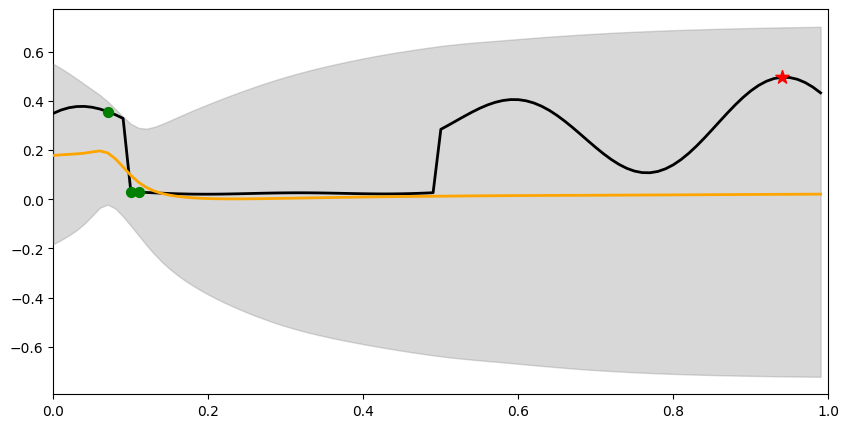

In [254]:
import pfns4bo
model = torch.load( pfns4bo.hebo_plus_model)
model.eval()

data_size = len(X)
pending_evaluations = list(range(data_size))
current_evaluations = []

init_ids = benchmark.bo_initializations[test_seed]
for i in range(len(init_ids)):
    idx = init_ids[i]
    pending_evaluations.remove(idx)
    current_evaluations.append(idx)


X_obs = torch.tensor(X[current_evaluations]).to(torch.float32)
X_pen = torch.tensor(X[pending_evaluations]).to(torch.float32)
y_t = torch.tensor(y[current_evaluations]).to(torch.float32)

x_full_feed = torch.cat([X_obs, X_pen], dim=0).unsqueeze(-1)
y_full_feed = torch.cat([y_t, torch.zeros(len(X_pen), 1)], dim=0)
layers_info = None

target_logits = model(
    (x_full_feed.repeat_interleave(dim=1, repeats=y_full_feed.shape[1]),
    y_full_feed.repeat(1,x_full_feed.shape[1])),
    single_eval_pos=len(X_obs),
    layers_info = layers_info
)

fig, ax = plt.subplots(figsize=(10, 5))



not_evaluated = np.setdiff1d(np.arange(data_size), current_evaluations)
ax.plot(X[not_evaluated], y[not_evaluated], linewidth=lw, label="Down Stream Task", zorder = 99, color = "black")


ax.scatter([X[y.argmax()]], [ y.max()], marker="*", s=100, c= "red", zorder = 99)
ax.scatter(X[current_evaluations],  y[current_evaluations], s= 50, c= "green", label="Observed Samples", zorder = 99)

median = model.criterion.median(target_logits).detach().numpy() 

# Plot median as a line
ax.plot(X[pending_evaluations].squeeze(), median[:, 0], color="orange", label="Median", linewidth=lw, zorder=99)
quantiles = model.criterion.quantile(target_logits, center_prob=0.75).detach().numpy() 
# Plot confidence interval as a shaded area
ax.fill_between(
    X[pending_evaluations].squeeze(),
    quantiles[:, 0, 1],
    quantiles[:, 0, 0],
    color="gray",
    alpha=0.3,
    label="Confidence Interval",
    zorder=98
)
ax.set_xlim(0, 1)

In [255]:
related_task_data = benchmark.get_meta_data()
converted_meta_data = dict()
max_length = 0
for task_uid, evaluations in related_task_data.items():
    _X = np.array([benchmark.search_space.to_numerical(e.configuration) for e in evaluations])
    _Y = -np.array([e.objectives["loss"] for e in evaluations]).reshape(-1) # return to maximization (performance)
    max_length = max(max_length, len(_Y))
    converted_meta_data[task_uid] = {"X": _X, "y": _Y}

x_task_context =[]
y_task_context = []
padding_mask = []
for k, item in converted_meta_data.items():
    x_task_context.append(np.concatenate([item["X"], np.zeros((max_length - item["X"].shape[0] , item["X"].shape[1]))]))
    y_task_context.append(np.concatenate( [item["y"] , np.zeros((max_length - item["y"].shape[0]))]))  
    padding_mask.append(np.concatenate([np.zeros(item["y"].shape[0]),  np.ones(max_length- item["y"].shape[0])]  ))
x_task_context = torch.tensor(np.stack(x_task_context, axis=1)).to(torch.float32)
y_task_context =  torch.tensor(np.stack(y_task_context, axis=1)).to(torch.float32)
padding_mask =  torch.tensor(np.stack(padding_mask, axis=1)).to(torch.bool).T 

/tmp/ipykernel_20962/3978044117.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = matplotlib.cm.get_cmap('tab10')


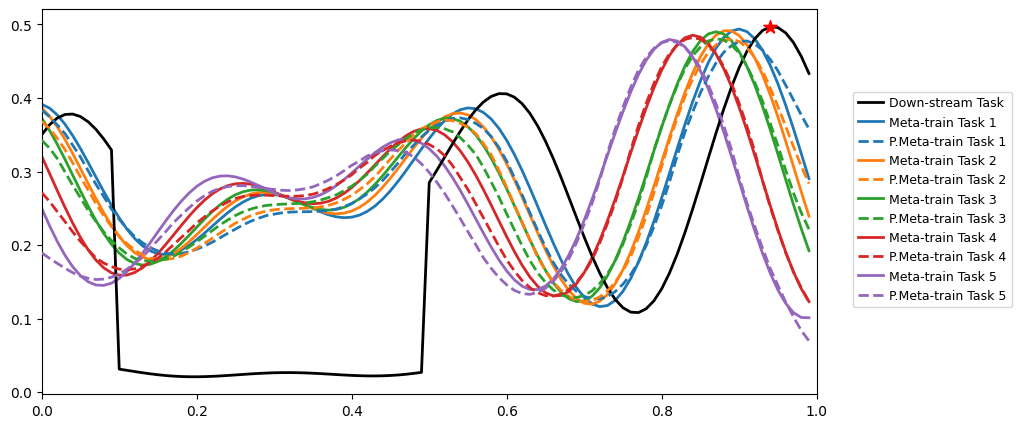

In [256]:
num_related = x_task_context.shape[1]

meta_logits = model(
            (torch.cat([
            x_task_context,
            X_obs.unsqueeze(1).repeat(1, num_related, 1),
            X_pen.unsqueeze(1).repeat(1, num_related, 1),
            ], dim=0),
            y_task_context),
            single_eval_pos=x_task_context.shape[0])
attention_outputs = model.get_attention_outputs()
hidden_state_outputs = model.get_hidden_state_outputs()

# output = {k: v(hidden_state_outputs[-1, x_task_context.shape[0]:]) for k,v in model.decoder_dict.items()}['standard']
# meta_logits = output

fig, ax = plt.subplots(figsize=(10, 5))

not_init = np.setdiff1d(np.arange(data_size), init_ids)
ax.plot(X[not_init], y[not_init], linewidth=lw, label="Down-stream Task", zorder = 99, color = "black")
ax.scatter([X[y.argmax()]], [y.max()], marker="*", s=100, c= "red", zorder = 99)

task_names = ["Meta-train Task 1", "Meta-train Task 2", "Meta-train Task 3", "Meta-train Task 4", "Meta-train Task 5"]
color_map = matplotlib.cm.get_cmap('tab10')

for i, (k, mdata) in enumerate(meta_data.items()):
        mX = np.array([benchmark.search_space.to_numerical(e.configuration) for e in mdata])
        mY = - np.array([e.objectives["loss"] for e in mdata]).reshape(-1) # return to maximization (performance)
        sort_idx = np.argsort(mX.flatten())
        ax.plot(mX[sort_idx], mY[sort_idx], linewidth=lw, label=task_names[i], color=color_map(i))

        median = model.criterion.median(meta_logits[X_obs.shape[0]:,i]).detach().numpy() 
        ax.plot(X[pending_evaluations].squeeze(), median, color=color_map(i), label="P." + task_names[i], linewidth=lw, zorder=99, linestyle='--')

ax.set_xlim(0,1)


lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]


anchor = (0.93, 0, 0.5, 1)
fig.legend(lines, labels,loc="center left", bbox_to_anchor=anchor, ncol=1, fontsize=fontsize*0.5,  handletextpad=0.5, labelspacing = 0.5, columnspacing=1.)
fig.subplots_adjust(wspace=0.2)

In [234]:
hidden_state_outputs.shape

torch.Size([12, 206, 5, 512])

(0.0, 1.0)

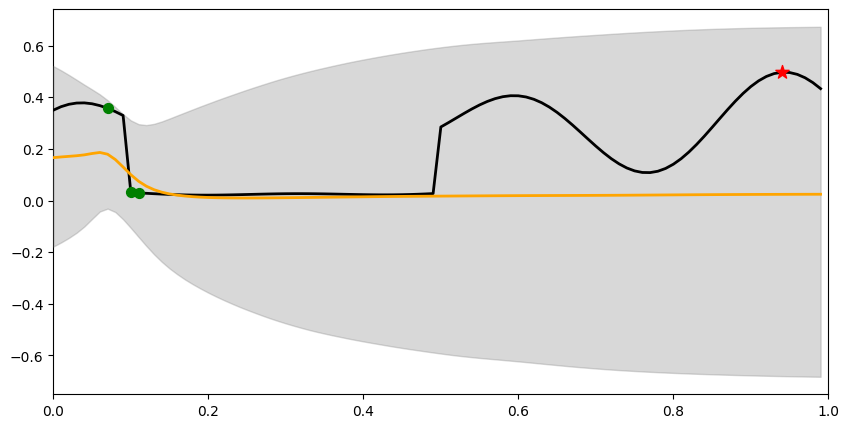

In [301]:

def mixing_strategy(src, src_meta = None, mix_rate =0.1):
    return mix_rate * src_meta.unsqueeze(1)  + (1 - mix_rate) * src

def f_support_attn(src_left, src_ ,self_attn,  src_meta = None, mix_rate =1.0):
    src_meta_attn = self_attn(src_, src_meta.unsqueeze(1), src_meta.unsqueeze(1))[0]
    return mix_rate * src_meta_attn  + (1 - mix_rate) * src_left


aggreated_outputs = torch.mean(attention_outputs[:,x_task_context.shape[0]:], dim=2)
#aggreated_outputs = hidden_state_outputs[:,x_task_context.shape[0]:, 0, :]
layers_info = []
for layer in range(len(aggreated_outputs)):
    if layer < 6:
        layers_info.append(( layer ,  {"f_attn": partial(mixing_strategy, src_meta = aggreated_outputs[layer]) } ))
    else:
        layers_info.append(( layer ,  {} ))

target_logits = model(
    (x_full_feed.repeat_interleave(dim=1, repeats=y_full_feed.shape[1]),
    y_full_feed.repeat(1,x_full_feed.shape[1])),
    single_eval_pos=len(X_obs),
    layers_info = layers_info
)


fig, ax = plt.subplots(figsize=(10, 5))

not_evaluated = np.setdiff1d(np.arange(data_size), current_evaluations)
ax.plot(X[not_evaluated], y[not_evaluated], linewidth=lw, label="Down Stream Task", zorder = 99, color = "black")

ax.scatter([X[y.argmax()]], [ y.max()], marker="*", s=100, c= "red", zorder = 99)
ax.scatter(X[current_evaluations],  y[current_evaluations], s= 50, c= "green", label="Observed Samples", zorder = 99)

median = model.criterion.median(target_logits).detach().numpy() 

# Plot median as a line
ax.plot(X[pending_evaluations].squeeze(), median[:, 0], color="orange", label="Median", linewidth=lw, zorder=99)
quantiles = model.criterion.quantile(target_logits, center_prob=0.75).detach().numpy() 
# Plot confidence interval as a shaded area
ax.fill_between(
    X[pending_evaluations].squeeze(),
    quantiles[:, 0, 1],
    quantiles[:, 0, 0],
    color="gray",
    alpha=0.3,
    label="Confidence Interval",
    zorder=98
)
ax.set_xlim(0, 1)